## Challenge TotalEnergies

Our purpose is to predict the quantity of energy produce by a central across several 48-hour periods

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

VERBOSE = True

## Load data

In [2]:
df = pd.read_csv('train.csv',delimiter=';',decimal=',',na_values=["#VALEUR!"],index_col="time")
df.index = pd.to_datetime(df.index, format='%d/%m/%Y %H:%M')

test = pd.read_csv('test.csv',delimiter=';',decimal=',',na_values=["#VALEUR!"],index_col="time")
test.index = pd.to_datetime(test.index, format='%d/%m/%Y %H:%M')

#### First look

In [3]:
df.head()

,Amb temp °C,Comp inlet temp °C,amb pressure,HR %,C/H,Network Frequency (Hz),Lower Heating Value (Wh/Nm3),EOH (h),DP filtre,CTRL anti givrage,IGV %,Net Power (MW)
time,,,,,,,,,,,,
2022-01-01 00:00:00,2.415345,13.756624,1009.650948,77.891805,NaN,44.799709,NaN,25523.87408,1.566854,-1.289541,-1.575997,8.292017
2022-01-01 00:01:00,2.410162,13.754808,1009.653573,78.010106,NaN,44.799660,NaN,25523.87408,1.566860,-1.284832,-1.575923,8.300175
2022-01-01 00:02:00,2.404979,13.752992,1009.656258,78.128415,NaN,44.799614,NaN,25523.87408,1.566866,-1.280124,-1.575849,8.308332
2022-01-01 00:03:00,2.399796,13.751176,1009.658883,78.246716,NaN,44.799565,NaN,25523.87408,1.566872,-1.275416,-1.575776,8.316489
2022-01-01 00:04:00,2.394613,13.749360,1009.658883,78.365018,NaN,44.799519,NaN,25523.87408,1.566878,-1.270708,-1.575702,8.324646


In [4]:
df.shape

(368581, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 368581 entries, 2022-01-01 00:00:00 to 2023-01-01 00:00:00
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Amb temp °C                   368502 non-null  float64
 1   Comp inlet temp °C            368517 non-null  float64
 2   amb pressure                  368572 non-null  float64
 3   HR %                          368553 non-null  float64
 4   C/H                           368536 non-null  float64
 5   Network Frequency (Hz)        368219 non-null  float64
 6   Lower Heating Value (Wh/Nm3)  368063 non-null  float64
 7   EOH (h)                       367002 non-null  float64
 8   DP filtre                     368553 non-null  float64
 9   CTRL anti givrage             368519 non-null  float64
 10  IGV %                         368341 non-null  float64
 11  Net Power (MW)                368207 non-null  float64
dtypes: float64

All of our datas as the right Dtype we can continue

In [6]:
df.describe()

,Amb temp °C,Comp inlet temp °C,amb pressure,HR %,C/H,Network Frequency (Hz),Lower Heating Value (Wh/Nm3),EOH (h),DP filtre,CTRL anti givrage,IGV %,Net Power (MW)
count,368502.000000,368517.000000,368572.000000,368553.000000,368536.000000,368219.000000,368063.000000,367002.000000,368553.000000,368519.000000,368341.000000,368207.000000
mean,14.487902,19.880848,992.565003,61.181880,3.288417,44.976282,10771.497116,27108.533262,2.726039,-10.856125,21.541416,116.847774
std,7.576516,7.326484,8.702163,17.264710,0.015378,1.313475,108.693864,934.778961,1.806945,7.073100,39.018238,169.242280
min,-1.092109,1.520982,948.226082,5.427441,3.208825,41.268475,518.654730,25523.874080,1.227618,-38.742719,-4.989705,1.259763
25%,8.056436,15.194340,987.967126,49.381600,3.276918,44.776016,10735.220820,26594.225637,1.566103,-15.450205,-2.691857,8.793495
50%,14.180040,20.892922,993.306435,65.136250,3.287632,44.791741,10763.482070,27019.401420,1.578827,-10.275179,-2.363789,9.631217
75%,19.532917,25.142531,998.070473,75.373906,3.301645,46.266140,10805.505570,27363.696340,4.621535,-4.644795,42.333016,298.661378
max,42.857579,43.273121,1012.959786,91.678914,3.579373,46.359951,10989.565000,29407.241270,7.250754,0.997576,203.764500,434.143647


The training set contains 368591 rows and 12 columns.

Here is the list of the columns of the dataset :

<table border="0" padding="0" margin="0">
<tbody>
<tr><td>Amb temp (°C)</td><td>Température ambiante</td></tr>
<tr><td>Comp inlet temp (°C)</td><td>Température entrée compresseur</td></tr>
<tr><td>amb pressure</td><td>Pression ambiante</td></tr>
<tr><td>HR %</td><td>%Humidité relative ambiante</td></tr>
<tr><td>C/H</td><td>Rapport Carbonne/hydrogène du Gaz Nat</td></tr>
<tr><td>Network Frequency (Hz)</td><td>Fréquence du réseau électrique en Hz</td></tr>
<tr><td>Lower Heating Value (Wh/Nm3) &nbsp;</td><td>le pouvoir calorifique inférieur du Gaz Nat</td></tr>
<tr><td>EOH (h)</td><td>Heures d'Opérations Equivalentes </td></tr>
<tr><td>DP filtre</td><td>Perte de charge au niveau des filtres d'air entrée turbine à gaz</td></tr>
<tr><td>CTRL anti givrage</td><td>Control de la vanne d'ouverture de l'anti-givre entrée turbine gaz</td></tr>
<tr><td>IGV %</td><td>% d'ouverture de la valve IGV (Inlet Guide Vanes) afin de controller la charge de la CCGT</td></tr>
<tr><td>Net Power (MW)</td><td>Production d'électricité NETTE générée par la CCGT</td></tr>
</tbody>
</table>

## Now let's deal with the missing values

In [7]:
if VERBOSE:
    print(df.isna().sum())

Amb temp °C                       79
Comp inlet temp °C                64
amb pressure                       9
HR %                              28
C/H                               45
Network Frequency (Hz)           362
Lower Heating Value (Wh/Nm3)     518
EOH (h)                         1579
DP filtre                         28
CTRL anti givrage                 62
IGV %                            240
Net Power (MW)                   374
dtype: int64


#### Imputing strategy

In [8]:
def imputed(data, method = 'lissage', n = 5, verbose = False, target = ['Net Power (MW)']):
    
    data.dropna(subset = target, inplace = True)
    if data.isna().sum().sum() == 0:
        return data

    data_imputed = data.copy()
    
    missing_cols = data.columns[data.isna().any()].tolist()

    for col in missing_cols:
        # Identifier les positions des valeurs manquantes
        missing_positions = data_imputed[col].isna()

        # Lissage exponentiel des valeurs manquantes
        if method == 'lissage':
            data_imputed.loc[missing_positions, col] = data_imputed[col].ewm(span=n, adjust=False).mean()
            
        elif method == 'KNN':
            from sklearn.impute import KNNImputer
            knn_imputer = KNNImputer(n_neighbors=n)
            data_imputed = knn_imputer.fit_transform(data_imputed[col])
        elif method == 'drop':
            data.dropna(inplace=True)
        if verbose:
            plt.figure(figsize=(12, 6))
            plt.plot(data[col], label='Données originales')
            plt.plot(data_imputed[col], label='Données imputées (lissage)', linestyle='dashed')
            plt.show()
        
    return data_imputed

In [9]:
data = df.copy()
data = imputed(data)
data.shape

(368207, 12)

<AxesSubplot:xlabel='time'>

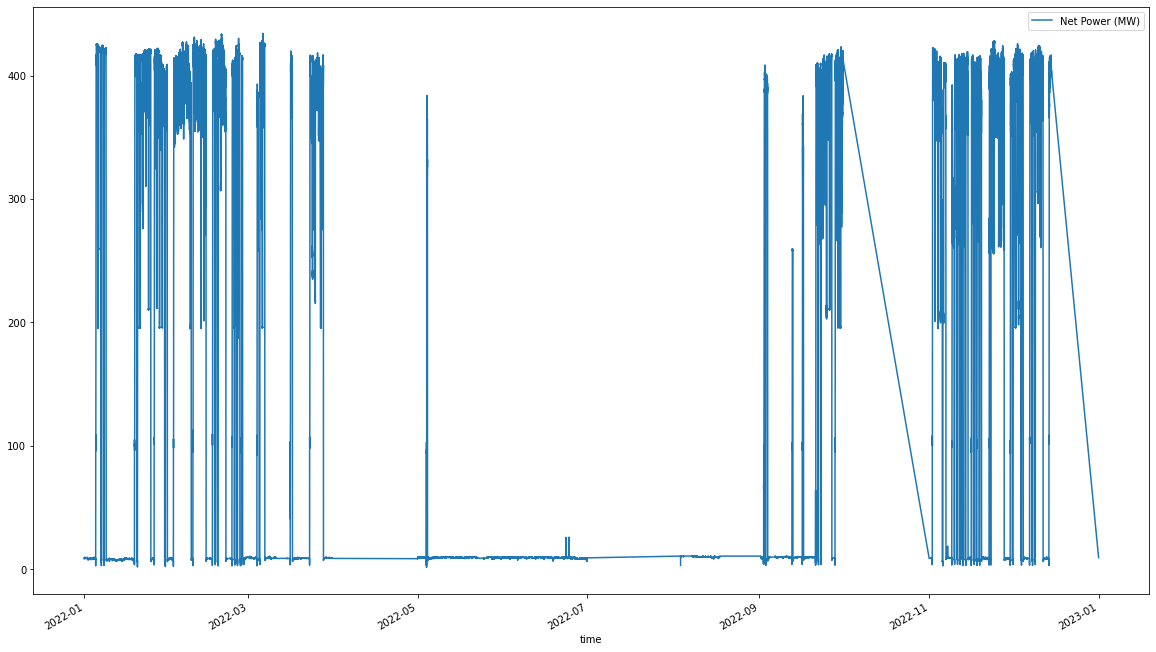

In [56]:
df.plot(y = "Net Power (MW)",figsize = (20, 12))

Lower Heating Value (Wh/Nm3)    0.036089
EOH (h)                         0.061113
C/H                             0.080483
amb pressure                    0.121627
Network Frequency (Hz)          0.242216
HR %                            0.243740
CTRL anti givrage               0.399421
Amb temp °C                     0.410624
Comp inlet temp °C              0.697693
IGV %                           0.971708
DP filtre                       0.991801
Net Power (MW)                  1.000000
Name: Net Power (MW), dtype: float64


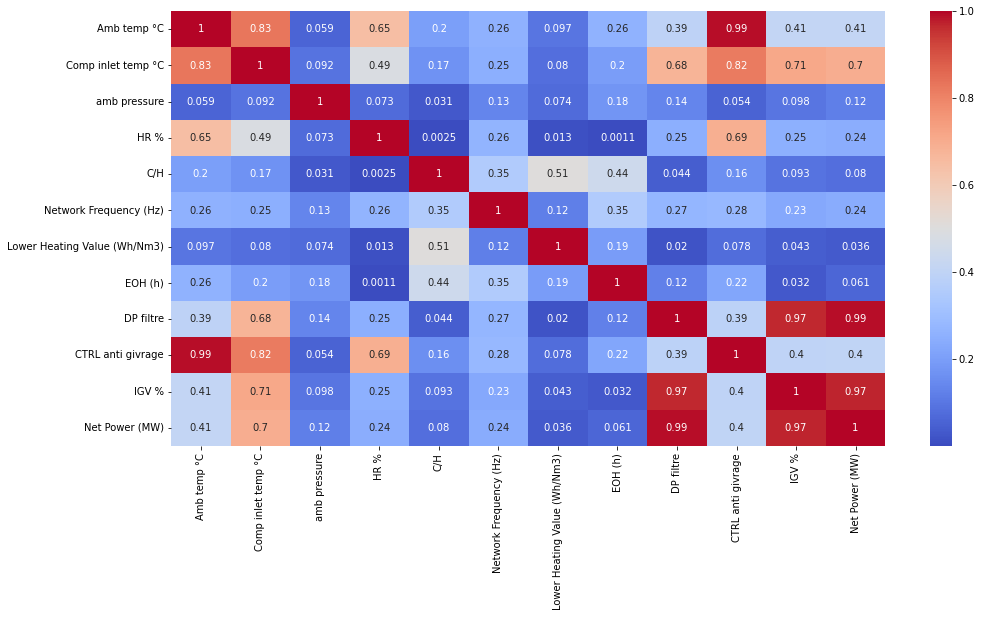

In [61]:
print(abs(df.corr())['Net Power (MW)'].sort_values(ascending=True ))
if VERBOSE:
    fig, ax = plt.subplots(figsize=(16,8))
    sns.heatmap(abs(df.corr()),cmap='coolwarm',annot=True)

#### What does our target look like ? (Net Power (MW))

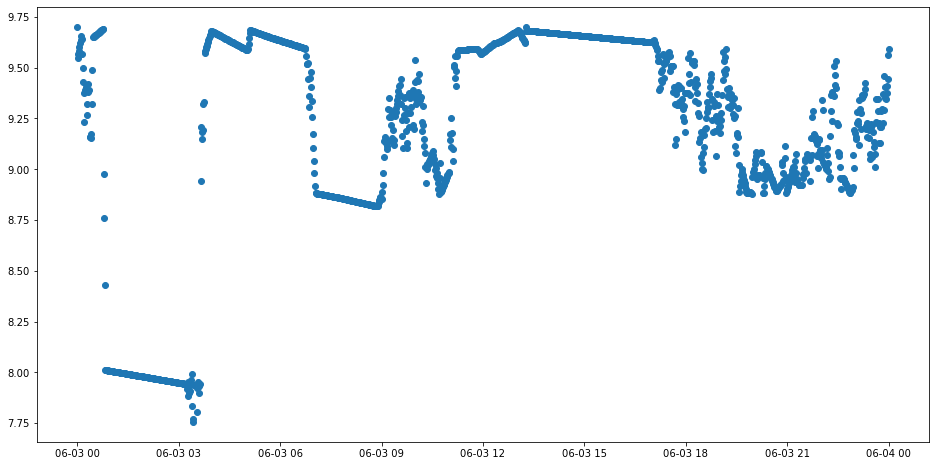

In [59]:
dt = data[(data.index >= "2022-06-03 00:00:00") & (data.index <= "2022-06-04 00:00:00")]
plt.figure(figsize=(16,8))
plt.scatter(dt.index,dt["Net Power (MW)"])

conclusion:

#### how each variable is related to the target ?

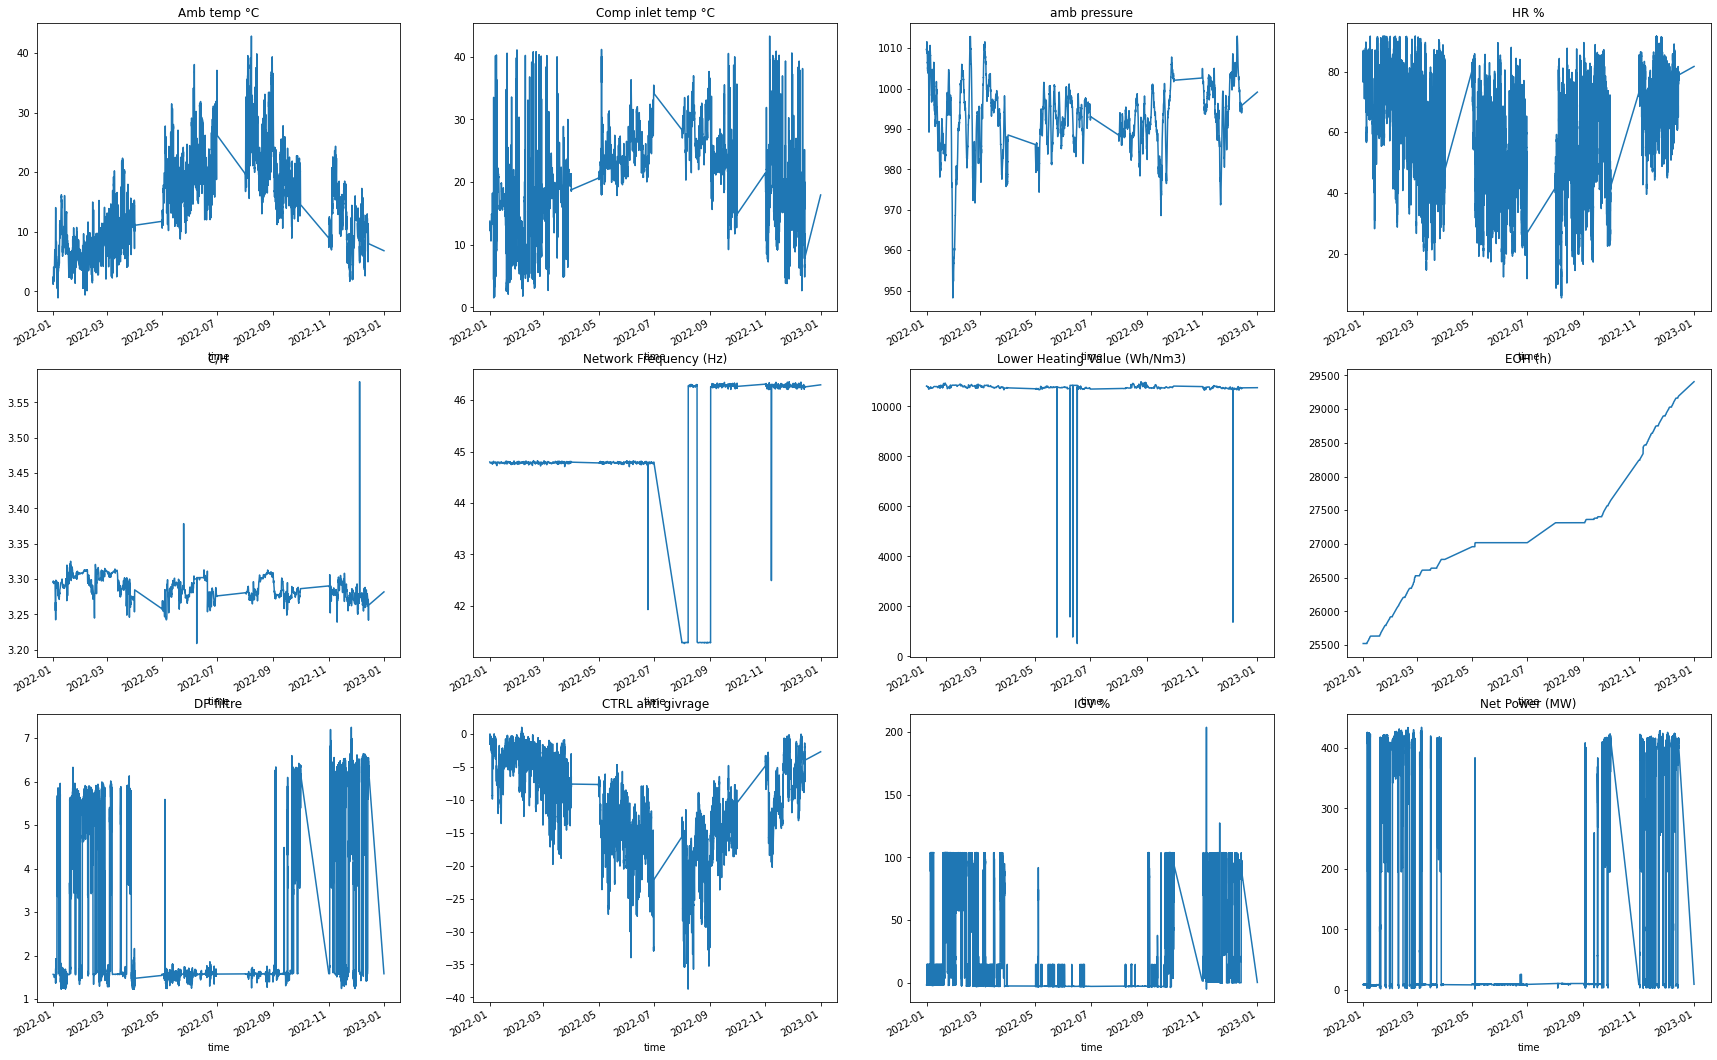

In [11]:
if VERBOSE:
    fig, ax = plt.subplots(figsize=(30,20),nrows=3, ncols=4)
    for i,col in enumerate(data.columns):
        data[col].plot(ax=ax[i//4,i%4],title=col)

amb pressure              0.121631
Network Frequency (Hz)    0.242216
HR %                      0.243740
CTRL anti givrage         0.399421
Amb temp °C               0.410624
Comp inlet temp °C        0.697693
IGV %                     0.971711
DP filtre                 0.991801
Net Power (MW)            1.000000
Name: Net Power (MW), dtype: float64


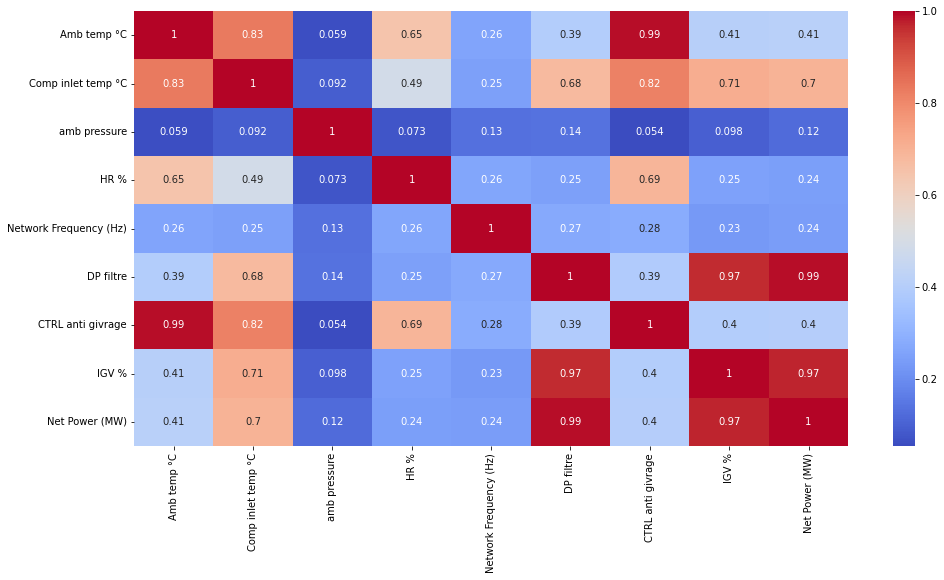

In [60]:
print(abs(data.corr())['Net Power (MW)'].sort_values(ascending=True ))
if VERBOSE:
    fig, ax = plt.subplots(figsize=(16,8))
    sns.heatmap(abs(data.corr()),cmap='coolwarm',annot=True)

'DP filtre' and 'IGV %' are highly correlated with the target variable.

'Amb Temp' and 'CTRL anti givrage' are highly correlated that's logic because the usage of anti icing depend on the ambient temperature

the less relevant variables are EOH (h) , C/H and Lower Heating Value (Wh/Nm3) considering the threeshhold as 0.1 but let's keep in mind that it can be useful depending on our model

In [13]:
data.drop(['C/H','Lower Heating Value (Wh/Nm3)','EOH (h)'],axis = 1,inplace = True)

In [14]:
FEATURES = ['Amb temp °C', 'Comp inlet temp °C', 'HR %','Network Frequency (Hz)', 'amb pressure','DP filtre', 'CTRL anti givrage', 'IGV %',]
TARGET = 'Net Power (MW)'

## Modeling

train every time for every model on all the dataset can be a little tough for my old little computer

##### so here is a function to reduce the dataset size in order to figure out the best model before training it on all the dataset

In [15]:
def convert_minutes(data, n):
 
    # Regrouper les données par intervalle de n minutes
    data_minutes = pd.DataFrame()
    for month in data.index.month.unique():
        data_minutes = pd.concat([data_minutes, data[data.index.month == month].resample(f'{n}T').mean()]) 
        
    data_minutes = data_minutes.dropna(how = 'all')
    
    return data_minutes

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [17]:
def train_test_split_local(data, target:str, train_size : float):
    
    premiere = data[data.index.month.isin([1, 2, 3])]
    deuxieme = data[data.index.month.isin([4, 5, 6])]
    troisieme = data[data.index.month.isin([7, 8, 9])]
    quatrieme = data[data.index.month.isin([10, 11, 12])]
    
    trainset = pd.DataFrame()
    testset = pd.DataFrame()
    
    for period in [premiere, deuxieme, troisieme, quatrieme]:
        
        train, test =  train_test_split(period, shuffle =  True, random_state = 42, train_size=train_size) 

        trainset = pd.concat([trainset, train])
        testset = pd.concat([testset, test])
        
    
        
    return trainset.drop(target, axis = 1), testset.drop(target, axis = 1), trainset[target], testset[target] 

In [18]:
# Evaluation simple de la performance 

def evaluate_model(model, X_train, Y_train, X_test, Y_test, verbose = True) : 
    
    print("Model name: ", type(model).__name__)
    if verbose :
        print("Model parameters: ", model.get_params())

    # Printing model accuracy
    model_train_mae  = mean_absolute_error(  Y_train, model.predict(X_train) )
    model_test_mae = mean_absolute_error(  Y_test , model.predict(X_test)  )
    
    if verbose : 
        print("Model Mean Absolute error on the train set : %.2f" % model_train_mae)
        print("Model Mean Absolute error on the test set : %.2f" % model_test_mae)
    
    return model_train_mae, model_test_mae

In [19]:
# Ici il s'agit de la cross_validation

def custom_time_series_cv(data) : 
    
    months = data.index.month.unique()
    
    for month in months : 
        train_data = data[data.index.month != month]
        test_data = data[data.index.month == month]
        
        yield month, train_data, test_data
        
        
def cross_val_log(data, models : dict, target: str):
    
    model_mean_train_mae, model_mean_test_mae = {}, {}
    
    for model_name, model in models.items():
        
        print(" \n  ******************** \n ")
        print("Model name: ", type(model).__name__)
        print("Model parameters: ", model.get_params())
        
        model_train_mae, model_test_mae = {}, {}
    
        for month, trainset, testset in custom_time_series_cv(data):
            
            X_train, X_test, Y_train, Y_test = trainset.drop(target, axis = 1), testset.drop(target, axis = 1), trainset[target], testset[target] 
            
            model.fit(X_train, Y_train)

            model_train_mae[month] = mean_absolute_error(  Y_train, model.predict(X_train) )
            model_test_mae[month] = mean_absolute_error(  Y_test , model.predict(X_test)  )               

            
        print("\n Model Absolute error on the train set : ")
        print(model_train_mae)
        model_mean_train_mae[model_name] = np.mean(list(model_train_mae.values()))
        
        
        print("\n Model Absolute error on the test set : ")
        print(model_test_mae)
        model_mean_test_mae[model_name] = np.mean(list(model_test_mae.values()))
        
    return model_mean_train_mae, model_mean_test_mae
        
        

import of some famous regressor

In [20]:
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor

In [21]:
# liste des modèles à tester
seed = 0
models = {

        "KNN" : KNeighborsRegressor(n_neighbors= 5),
        "CART" : DecisionTreeRegressor(),

        "AdaBoostR" : AdaBoostRegressor(random_state=seed),
        "XGB" : XGBRegressor(random_state =  seed),
        "GradientBoostingR" : GradientBoostingRegressor(random_state=seed),

        "RandomForest" : RandomForestRegressor(random_state=seed),
        "ExtraTreesRegressor" : ExtraTreesRegressor(random_state=seed),

    }

In [35]:
df_heure = convert_minutes(data, n= 60)

#### simple evaluation of each of our model

In [36]:
X_train, X_test,y_train, y_test =  train_test_split_local(df_heure, TARGET, train_size=0.75) 

for model_name, model in models.items():
        
        model.fit(X_train, y_train)

        scores = evaluate_model(model, X_train, y_train, X_test, y_test)
        
        print("\n \n ")

Model name:  KNeighborsRegressor
Model parameters:  {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Model Mean Absolute error on the train set : 4.15
Model Mean Absolute error on the test set : 5.02

 
 
Model name:  DecisionTreeRegressor
Model parameters:  {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'random_state': None, 'splitter': 'best'}
Model Mean Absolute error on the train set : 0.00
Model Mean Absolute error on the test set : 2.58

 
 
Model name:  AdaBoostRegressor
Model parameters:  {'base_estimator': 'deprecated', 'estimator': None, 'learning_rate': 1.0, 'loss': 'linear', 'n_estimators': 50, 'random_state': 0}
Model Mean Absolute error on the train set : 4.04
Model Mean Absolute error on the test se

confirmons les meilleurs modèles 

In [37]:
# liste des modèles à tester
seed = 0
models = {
        "XGB" : XGBRegressor(random_state =  seed),
        "RandomForest" : RandomForestRegressor(random_state=seed),
        "ExtraTreesRegressor" : ExtraTreesRegressor(random_state=seed),
    }

#### Cross validation 

In [38]:
results_train, results_test = cross_val_log(df_heure, models, TARGET)

results_train = pd.DataFrame.from_dict(results_train, 'index')
results_test = pd.DataFrame.from_dict(results_test, 'index')

best_results_train, best_results_test = results_train.sort_values(by = 0, ascending =  True), results_test.sort_values(by = 0, ascending =  True)
     

 
  ******************** 
 
Model name:  XGBRegressor
Model parameters:  {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'gpu_id': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'predictor': None, 'random_state': 0, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

 Model Absolute error on the train

In [39]:
best_results_train

,0
ExtraTreesRegressor,5.093766e-13
XGB,3.998686e-01
RandomForest,6.997937e-01


In [40]:
best_results_test

,0
ExtraTreesRegressor,2.929753
RandomForest,2.985493
XGB,3.312118


On choisis ExtraTreesRegressor pour continuer 

to enhance our models accuracy we can bring them more relevant variables 

###### adding some time features

In [45]:
def time_features_creation(data): 
    datac = data.copy()
    datac['hour'] = datac.index.hour
    datac['dayofweek'] = datac.index.dayofweek
    datac['quarter'] = datac.index.quarter
    datac['month'] = datac.index.month
    datac['dayofyear'] = datac.index.dayofyear
    return datac

In [46]:
data_w_time = time_features_creation(df_heure)
data_w_time.head()

,Amb temp °C,Comp inlet temp °C,amb pressure,HR %,Network Frequency (Hz),DP filtre,CTRL anti givrage,IGV %,Net Power (MW),hour,dayofweek,quarter,month,dayofyear
time,,,,,,,,,,,,,,
2022-01-01 00:00:00,2.247770,13.595904,1009.645425,78.435817,44.798300,1.567028,-1.276771,-1.573826,8.522513,0,5,1,1,1
2022-01-01 01:00:00,1.511082,13.263483,1009.760749,81.723051,44.795434,1.567156,-0.779448,-1.569412,8.944603,1,5,1,1,1
2022-01-01 02:00:00,1.302638,12.956593,1009.650130,85.041355,44.792569,1.567156,-0.288329,-1.564997,9.054717,2,5,1,1,1
2022-01-01 03:00:00,1.551172,12.787507,1009.564445,85.492619,44.789704,1.567156,-0.257616,-1.565520,9.137607,3,5,1,1,1
2022-01-01 04:00:00,1.799590,12.703127,1009.362386,85.726440,44.786897,1.567156,-0.206388,-1.585577,9.169518,4,5,1,1,1


In [64]:
models = {
        "ExtraTreesRegressor" : ExtraTreesRegressor(random_state=0),
    }

In [65]:
results_train, results_test = cross_val_log(data_w_time, models, TARGET)

results_train = pd.DataFrame.from_dict(results_train, 'index')
results_test = pd.DataFrame.from_dict(results_test, 'index')

best_results_train, best_results_test = results_train.sort_values(by = 0, ascending =  True), results_test.sort_values(by = 0, ascending =  True)

 
  ******************** 
 
Model name:  ExtraTreesRegressor
Model parameters:  {'bootstrap': False, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}

 Model Absolute error on the train set : 
{1: 3.8712730137239633e-13, 2: 2.4066014263679734e-13, 3: 1.2439071196799654e-13, 5: 5.452902137071873e-13, 6: 1.3676915659685118e-13, 8: 1.371706040934576e-13, 9: 1.2156708690237853e-13, 11: 1.0750677367882248e-13, 12: 1.1531924418331428e-13}

 Model Absolute error on the test set : 
{1: 4.031588853805892, 2: 5.803339770179844, 3: 2.6113903415252837, 5: 0.4854420661523577, 6: 0.4403420802524912, 8: 0.31496706160146887, 9: 4.117886957252205, 11: 4.926689832818023, 12: 3.288922916061909}


In [66]:
best_results_test

,0
ExtraTreesRegressor,2.891174


Better.let's try an another feature

###### adding a diff column

In [69]:
def difference(data, target = "Net Power (MW)"):
    
    diff = data.drop(target, axis = 1).diff().fillna(0)
    dicto = {}
    
    for col in list(diff.columns):
        dicto[col] = f"{col}_diff"
    
    diff = diff.rename(columns=dicto)
    
    return pd.concat([data, diff], axis = 1)

In [70]:
df_diff = difference(df_heure)
df_diff.head()

,Amb temp °C,Comp inlet temp °C,amb pressure,HR %,Network Frequency (Hz),DP filtre,CTRL anti givrage,IGV %,Net Power (MW),Amb temp °C_diff,Comp inlet temp °C_diff,amb pressure_diff,HR %_diff,Network Frequency (Hz)_diff,DP filtre_diff,CTRL anti givrage_diff,IGV %_diff
time,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,2.247770,13.595904,1009.645425,78.435817,44.798300,1.567028,-1.276771,-1.573826,8.522513,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-01-01 01:00:00,1.511082,13.263483,1009.760749,81.723051,44.795434,1.567156,-0.779448,-1.569412,8.944603,-0.736688,-0.332421,0.115325,3.287235,-0.002865,0.000128,0.497323,0.004414
2022-01-01 02:00:00,1.302638,12.956593,1009.650130,85.041355,44.792569,1.567156,-0.288329,-1.564997,9.054717,-0.208444,-0.306891,-0.110619,3.318303,-0.002865,0.000000,0.491119,0.004414
2022-01-01 03:00:00,1.551172,12.787507,1009.564445,85.492619,44.789704,1.567156,-0.257616,-1.565520,9.137607,0.248534,-0.169085,-0.085685,0.451265,-0.002865,0.000000,0.030714,-0.000523
2022-01-01 04:00:00,1.799590,12.703127,1009.362386,85.726440,44.786897,1.567156,-0.206388,-1.585577,9.169518,0.248417,-0.084380,-0.202059,0.233820,-0.002807,0.000000,0.051227,-0.020057


In [71]:
results_train, results_test = cross_val_log(df_diff, models, TARGET)

results_train = pd.DataFrame.from_dict(results_train, 'index')
results_test = pd.DataFrame.from_dict(results_test, 'index')

best_results_train, best_results_test = results_train.sort_values(by = 0, ascending =  True), results_test.sort_values(by = 0, ascending =  True)

 
  ******************** 
 
Model name:  ExtraTreesRegressor
Model parameters:  {'bootstrap': False, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}

 Model Absolute error on the train set : 
{1: 6.595010293336276e-13, 2: 1.1266919958454354e-12, 3: 1.0845258958554441e-12, 5: 1.362259364634682e-12, 6: 1.3676915659685118e-13, 8: 4.093874210824382e-13, 9: 9.492327412641445e-13, 11: 5.141781504442776e-13, 12: 8.748733356399429e-13}

 Model Absolute error on the test set : 
{1: 3.444876429037773, 2: 3.6022587893832374, 3: 1.8659158126589437, 5: 0.49599501175037136, 6: 0.46253849879880965, 8: 0.2520973885634005, 9: 2.7459591828527956, 11: 3.039245604891207, 12: 2.1872010892131746}


In [72]:
best_results_test

,0
ExtraTreesRegressor,2.010676


okay definetly a good feature to keep with

let's try to combine the two features we got and see what happening

In [73]:
from sklearn.pipeline import Pipeline, FunctionTransformer
data_transform_pipeline = Pipeline([
    ('difference', FunctionTransformer(lambda x : difference(x))),
    ('time', FunctionTransformer(lambda x : time_features_creation(x))),
    ])

In [75]:
df_w2nfeatures = data_transform_pipeline.transform(df_heure)
results_train, results_test = cross_val_log(df_w2nfeatures, models, TARGET)

results_train = pd.DataFrame.from_dict(results_train, 'index')
results_test = pd.DataFrame.from_dict(results_test, 'index')

best_results_train, best_results_test = results_train.sort_values(by = 0, ascending =  True), results_test.sort_values(by = 0, ascending =  True)

 
  ******************** 
 
Model name:  ExtraTreesRegressor
Model parameters:  {'bootstrap': False, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}

 Model Absolute error on the train set : 
{1: 5.233136716462751e-13, 2: 1.0629644635550064e-13, 3: 3.9665794881565263e-13, 5: 1.3681106801147441e-13, 6: 1.3676915659685118e-13, 8: 2.9336862157665397e-13, 9: 2.57120281048209e-13, 11: 1.0750677367882248e-13, 12: 1.1531924418331428e-13}

 Model Absolute error on the test set : 
{1: 3.2835117565797765, 2: 3.9229676241648033, 3: 1.9483867716170147, 5: 0.4347132374896152, 6: 0.42955825843984724, 8: 0.3415254229724583, 9: 3.0170728042118697, 11: 2.9049813256708195, 12: 2.175745002627443}


In [76]:
best_results_test

,0
ExtraTreesRegressor,2.05094


we can see date time features we had add are not more relevant cause they don't bring any amelioration to our models

In [77]:
from sklearn.model_selection import GridSearchCV

ETR_grid = {
    'n_estimators' : [25, 50, 100, 150],
    'criterion' : ["absolute_error"],
    'max_depth' : [None, 10, 20],
    'n_jobs' : [-1]
}

X_train, X_test,Y_train, Y_test =  train_test_split_local(df_heure, TARGET, train_size=0.75)
grid_search = GridSearchCV(estimator=ExtraTreesRegressor(random_state=0), param_grid=ETR_grid, cv = 3, scoring='neg_mean_absolute_error')
grid_search.fit(X_train, Y_train)

ETR_model = grid_search.best_estimator_
grid_search.best_params_

{'criterion': 'absolute_error',
 'max_depth': None,
 'n_estimators': 50,
 'n_jobs': -1}

In [78]:
models = {
        "ExtraTreesRegressor" : ETR_model,
    }
results_train, results_test = cross_val_log(df_diff, models, TARGET)

results_train = pd.DataFrame.from_dict(results_train, 'index')
results_test = pd.DataFrame.from_dict(results_test, 'index')

 
  ******************** 
 
Model name:  ExtraTreesRegressor
Model parameters:  {'bootstrap': False, 'ccp_alpha': 0.0, 'criterion': 'absolute_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 50, 'n_jobs': -1, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}

 Model Absolute error on the train set : 
{1: 5.875126626113848e-14, 2: 5.412773621556403e-14, 3: 6.324212006707883e-14, 5: 7.02697543642408e-14, 6: 7.032941383658304e-14, 8: 7.055475545367126e-14, 9: 6.27376342605959e-14, 11: 5.573360536145937e-14, 12: 5.954849274912309e-14}

 Model Absolute error on the test set : 
{1: 3.2093328347413212, 2: 3.7058618023380476, 3: 2.0876463409218724, 5: 0.5241975838469314, 6: 0.4649832551191938, 8: 0.24913939189030748, 9: 3.0729328338318442, 11: 3.3208279930705937, 12: 2.176192265013198}


In [79]:
results_test

,0
ExtraTreesRegressor,2.090124


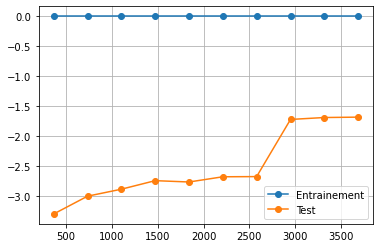

In [81]:
from sklearn.model_selection import learning_curve
X_train, X_test,Y_train, Y_test =  train_test_split_local(df_diff, TARGET, train_size=0.75)
train_sizes, train_mae, test_mae = learning_curve(model, X_train, Y_train, cv = 5, train_sizes= np.linspace(0.1, 1.0, 10), scoring = 'neg_mean_absolute_error')
plt.figure()
plt.grid()
plt.plot(train_sizes, train_mae.mean(axis = 1), 'o-', label = 'Entrainement')
plt.plot(train_sizes, test_mae.mean(axis = 1), 'o-', label = 'Test')
plt.show()

In [83]:
selected_model = ETR_model
df_diff = difference(data)
X = df_diff.drop('Net Power (MW)', axis = 1)
y = df_diff['Net Power (MW)']
ETR_model.fit(X,y)

KeyboardInterrupt: 

In [ ]:
X_test = test.drop(['Lower Heating Value (Wh/Nm3)', 'EOH (h)','C/H','Net Power (MW)'], axis = 1)
X_test = difference(X_test)
df_predictions = pd.DataFrame({'time': test.index,'Net Power (MW)': selected_model.predict(X_test)})
df_predictions.to_csv('prédiction', date_format='%d/%m/%Y %H:%M',index=False, sep=';')
df_predictions.head()